# Modeling Workflow

This notebook reads the existing processed train and test files, reuses the same SMOTENC balancing logic from `src/train_models.py`, and keeps every experiment in memory.

The train/test splits, preprocessing outputs, and dataset files are not overwritten here.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    roc_auc_score,
 )
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.train_models import PRIMARY_CLASSIFICATION_METRIC, balance_training_data, load_data

In [2]:
data = load_data()

X_train_balanced, y_train_balanced = balance_training_data(
    data["X_train"],
    data["y_train"],
    data["target_encoder"],
)

print("Notebook modeling uses the saved train/test tables only.")
print(f"Balanced training shape: {X_train_balanced.shape}")
print(f"Untouched test shape: {data['X_test'].shape}")

   X_train: (77837, 28)
   X_test: (19460, 28)
   y_train: (77837,)
   y_test: (19460,)
   Target classes: ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']

TRAINING DATA REBALANCING
   Applying SMOTENC to the training split only

Original class distribution:
   Gestational: 214 (0.3%)
   No Diabetes: 6,189 (8.0%)
   Pre-Diabetes: 24,810 (31.9%)
   Type 1: 94 (0.1%)
   Type 2: 46,530 (59.8%)

Resampled class distribution:
   Gestational: 46,530 (20.0%)
   No Diabetes: 46,530 (20.0%)
   Pre-Diabetes: 46,530 (20.0%)
   Type 1: 46,530 (20.0%)
   Type 2: 46,530 (20.0%)
Notebook modeling uses the saved train/test tables only.
Balanced training shape: (232650, 28)
Untouched test shape: (19460, 28)


In [3]:
def evaluate_model(model_name, model, X_fit, y_fit, X_test, y_test, target_encoder):
    class_labels = np.arange(len(target_encoder.classes_))
    model.fit(X_fit, y_fit)

    y_pred = model.predict(X_test)
    proba_frame = pd.DataFrame(
        model.predict_proba(X_test),
        columns=model.classes_,
    )
    y_proba = proba_frame.reindex(columns=class_labels, fill_value=0.0).to_numpy()

    confusion = confusion_matrix(y_test, y_pred, labels=class_labels)
    report = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            labels=class_labels,
            target_names=target_encoder.classes_,
            zero_division=0,
            output_dict=True,
        )
    ).transpose()

    metrics = {
        "Model": model_name,
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted ROC-AUC": roc_auc_score(
            y_test,
            y_proba,
            labels=class_labels,
            multi_class="ovr",
            average="weighted",
        ),
    }

    return {
        "model": model,
        "metrics": metrics,
        "confusion": confusion,
        "report": report,
    }

MODEL_BUILDERS = {
    "Decision Tree": lambda: DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        min_samples_split=40,
        random_state=42,
    ),
    "Random Forest": lambda: RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=20,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": lambda: xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1,
    ),
    "Extra Trees": lambda: ExtraTreesClassifier(
        n_estimators=250,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": lambda: HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=8,
        max_iter=250,
        min_samples_leaf=20,
        random_state=42,
    ),
}

In [4]:
evaluations = {}
comparison_rows = []

for model_name, build_model in MODEL_BUILDERS.items():
    result = evaluate_model(
        model_name=model_name,
        model=build_model(),
        X_fit=X_train_balanced,
        y_fit=y_train_balanced,
        X_test=data["X_test"],
        y_test=data["y_test"],
        target_encoder=data["target_encoder"],
    )
    evaluations[model_name] = result
    comparison_rows.append(result["metrics"])

comparison = pd.DataFrame(comparison_rows).sort_values(
    [PRIMARY_CLASSIFICATION_METRIC, "Balanced Accuracy", "Weighted ROC-AUC"],
    ascending=False,
).reset_index(drop=True)

display(
    comparison.style.format({
        "Macro F1": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "MCC": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted ROC-AUC": "{:.4f}",
    })
)

best_row = comparison.iloc[0]
print(
    f"Best model by {PRIMARY_CLASSIFICATION_METRIC}: "
    f"{best_row['Model']} ({best_row[PRIMARY_CLASSIFICATION_METRIC]:.4f})"
)

,Model,Macro F1,Accuracy,Balanced Accuracy,MCC,Macro Precision,Weighted Precision,Weighted ROC-AUC
0,Hist Gradient Boosting,0.5478,0.9053,0.5695,0.8395,0.5342,0.9217,0.9481
1,XGBoost,0.5461,0.8895,0.5741,0.8167,0.5351,0.9250,0.9468
2,Random Forest,0.5434,0.8763,0.5803,0.7996,0.5346,0.9240,0.9461
3,Decision Tree,0.5194,0.7904,0.5924,0.6837,0.5346,0.9224,0.9250
4,Extra Trees,0.5014,0.8364,0.5370,0.7192,0.4871,0.8696,0.9297


Best model by Macro F1: Hist Gradient Boosting (0.5478)


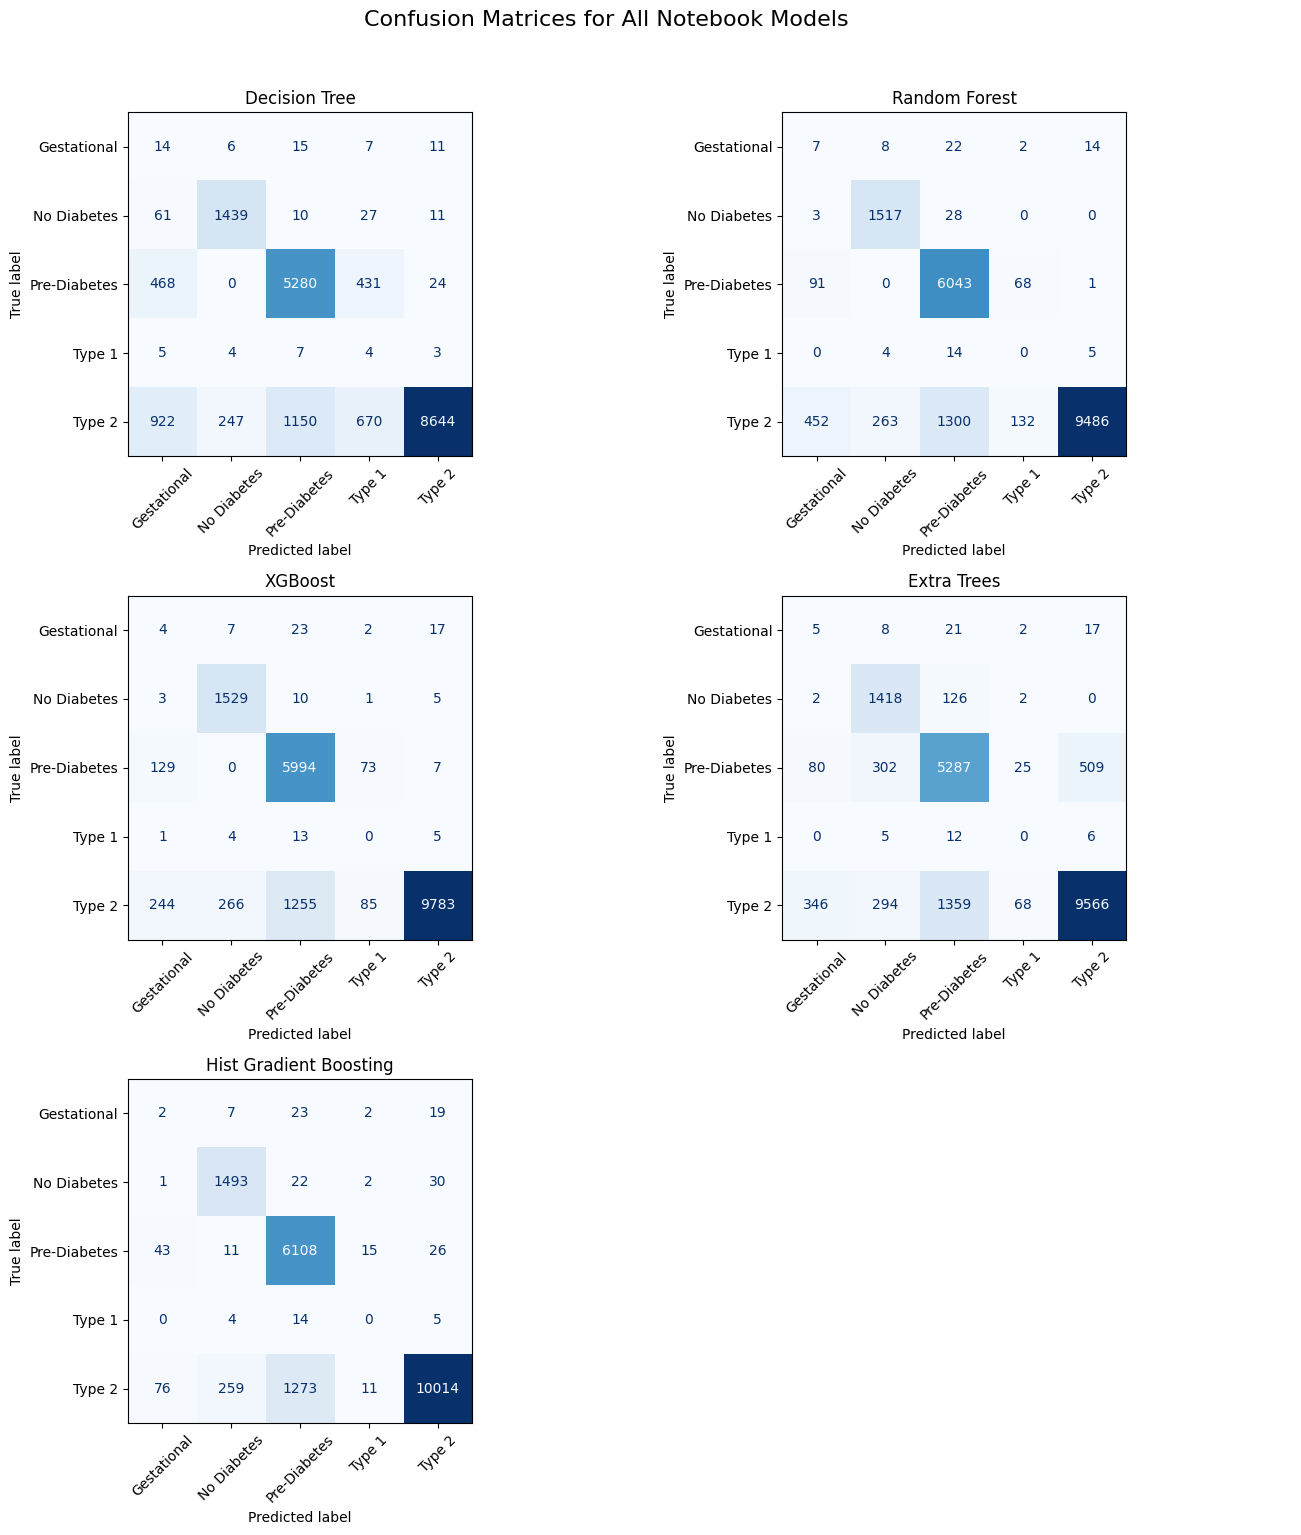

In [5]:
class_names = data["target_encoder"].classes_
model_names = list(evaluations.keys())
columns = 2
rows = int(np.ceil(len(model_names) / columns))

fig, axes = plt.subplots(rows, columns, figsize=(14, 5 * rows))
axes = np.atleast_1d(axes).ravel()

for axis, model_name in zip(axes, model_names):
    ConfusionMatrixDisplay(
        confusion_matrix=evaluations[model_name]["confusion"],
        display_labels=class_names,
    ).plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
    axis.set_title(model_name)
    axis.tick_params(axis="x", rotation=45)

for axis in axes[len(model_names):]:
    axis.axis("off")

fig.suptitle("Confusion Matrices for All Notebook Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
for model_name, result in evaluations.items():
    print(f"\n{model_name}")
    display(result["report"].round(3))


Decision Tree


,precision,recall,f1-score,support
Gestational,0.010,0.264,0.018,53.00
No Diabetes,0.848,0.930,0.887,1548.00
Pre-Diabetes,0.817,0.851,0.834,6203.00
Type 1,0.004,0.174,0.007,23.00
Type 2,0.994,0.743,0.851,11633.00
accuracy,0.790,0.790,0.790,0.79
macro avg,0.535,0.592,0.519,19460.00
weighted avg,0.922,0.790,0.845,19460.00



Random Forest


,precision,recall,f1-score,support
Gestational,0.013,0.132,0.023,53.000
No Diabetes,0.847,0.980,0.908,1548.000
Pre-Diabetes,0.816,0.974,0.888,6203.000
Type 1,0.000,0.000,0.000,23.000
Type 2,0.998,0.815,0.897,11633.000
accuracy,0.876,0.876,0.876,0.876
macro avg,0.535,0.580,0.543,19460.000
weighted avg,0.924,0.876,0.892,19460.000



XGBoost


,precision,recall,f1-score,support
Gestational,0.010,0.075,0.018,53.00
No Diabetes,0.847,0.988,0.912,1548.00
Pre-Diabetes,0.822,0.966,0.888,6203.00
Type 1,0.000,0.000,0.000,23.00
Type 2,0.997,0.841,0.912,11633.00
accuracy,0.890,0.890,0.890,0.89
macro avg,0.535,0.574,0.546,19460.00
weighted avg,0.925,0.890,0.901,19460.00



Extra Trees


,precision,recall,f1-score,support
Gestational,0.012,0.094,0.021,53.000
No Diabetes,0.700,0.916,0.793,1548.000
Pre-Diabetes,0.777,0.852,0.813,6203.000
Type 1,0.000,0.000,0.000,23.000
Type 2,0.947,0.822,0.880,11633.000
accuracy,0.836,0.836,0.836,0.836
macro avg,0.487,0.537,0.501,19460.000
weighted avg,0.870,0.836,0.849,19460.000



Hist Gradient Boosting


,precision,recall,f1-score,support
Gestational,0.016,0.038,0.023,53.000
No Diabetes,0.842,0.964,0.899,1548.000
Pre-Diabetes,0.821,0.985,0.895,6203.000
Type 1,0.000,0.000,0.000,23.000
Type 2,0.992,0.861,0.922,11633.000
accuracy,0.905,0.905,0.905,0.905
macro avg,0.534,0.570,0.548,19460.000
weighted avg,0.922,0.905,0.908,19460.000


## Patient Segmentation Visuals

This section displays the same two segmentation views added to the dashboard, but as notebook outputs instead of interactive web components.

The charts are built from the saved clustering artifacts in `data/train_clusters.csv`, `data/cluster_profiles.csv`, and `data/X_train_scaled.csv`.

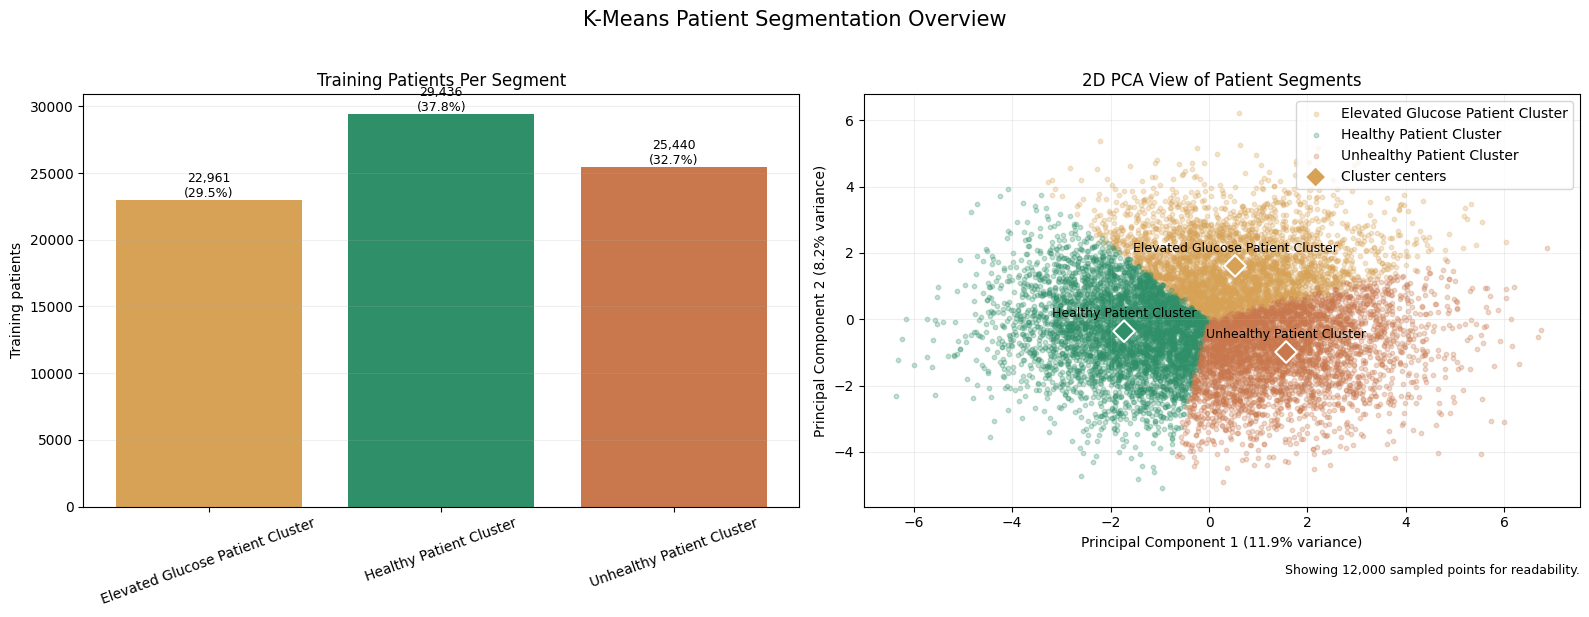

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

cluster_profiles_path = PROJECT_ROOT / "data" / "cluster_profiles.csv"
train_clusters_path = PROJECT_ROOT / "data" / "train_clusters.csv"
x_train_scaled_path = PROJECT_ROOT / "data" / "X_train_scaled.csv"

for required_path in (cluster_profiles_path, train_clusters_path, x_train_scaled_path):
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required segmentation file: {required_path}")

cluster_profiles = pd.read_csv(cluster_profiles_path)
train_clusters = pd.read_csv(train_clusters_path).squeeze("columns").astype(int)
x_train_scaled = pd.read_csv(x_train_scaled_path)

profile_columns = [
    "physical_activity_minutes_per_week",
    "diet_score",
    "bmi",
    "glucose_fasting",
    "hba1c",
]

segment_labels = {
    "healthy": "Healthy Patient Cluster",
    "elevated_glucose": "Elevated Glucose Patient Cluster",
    "unhealthy": "Unhealthy Patient Cluster",
}

segment_colors = {
    "healthy": "#2f8f68",
    "elevated_glucose": "#d7a255",
    "unhealthy": "#c9774c",
}

def build_cluster_segment_keys(profile_frame: pd.DataFrame) -> dict[int, str]:
    profiles = profile_frame.set_index("cluster")[profile_columns].apply(pd.to_numeric, errors="coerce")

    segment_keys: dict[int, str] = {}
    overall_health_rank = (
        profiles["physical_activity_minutes_per_week"].rank(method="dense", ascending=False)
        + profiles["diet_score"].rank(method="dense", ascending=False)
        + profiles["bmi"].rank(method="dense", ascending=True)
        + profiles["glucose_fasting"].rank(method="dense", ascending=True)
        + profiles["hba1c"].rank(method="dense", ascending=True)
    )
    healthiest_cluster = int(overall_health_rank.idxmin())
    segment_keys[healthiest_cluster] = "healthy"

    remaining_clusters = [cluster_id for cluster_id in profiles.index if int(cluster_id) not in segment_keys]
    if remaining_clusters:
        remaining_profiles = profiles.loc[remaining_clusters]
        glucose_risk_rank = (
            remaining_profiles["glucose_fasting"].rank(method="dense", ascending=False)
            + remaining_profiles["hba1c"].rank(method="dense", ascending=False)
        )
        highest_glucose_cluster = int(glucose_risk_rank.idxmin())
        segment_keys[highest_glucose_cluster] = "elevated_glucose"

    for cluster_id in profiles.index:
        cluster_id = int(cluster_id)
        if cluster_id not in segment_keys:
            segment_keys[cluster_id] = "unhealthy"

    return segment_keys

segment_keys = build_cluster_segment_keys(cluster_profiles)

cluster_profiles = cluster_profiles.copy()
cluster_profiles["cluster"] = pd.to_numeric(cluster_profiles["cluster"], errors="coerce").astype(int)
cluster_profiles["segment_key"] = cluster_profiles["cluster"].map(segment_keys)
cluster_profiles["cluster_name"] = cluster_profiles["segment_key"].map(segment_labels)
cluster_profiles["color"] = cluster_profiles["segment_key"].map(segment_colors)
cluster_profiles = cluster_profiles.sort_values("cluster").reset_index(drop=True)
cluster_profiles["cluster_share_pct"] = cluster_profiles["cluster_size"] / cluster_profiles["cluster_size"].sum() * 100

projection_frame = pd.DataFrame(PCA(n_components=2, random_state=42).fit_transform(x_train_scaled), columns=["pc1", "pc2"])
projection_frame["cluster"] = train_clusters.to_numpy()

max_points = 12000
is_sampled = len(projection_frame) > max_points
if is_sampled:
    sample_ratio = max_points / len(projection_frame)
    sampled_groups = []
    for _, cluster_frame in projection_frame.groupby("cluster", sort=False):
        sample_size = min(len(cluster_frame), max(1, int(round(len(cluster_frame) * sample_ratio))))
        sampled_groups.append(cluster_frame.sample(n=sample_size, random_state=42))
    projection_frame = pd.concat(sampled_groups, ignore_index=True)
    if len(projection_frame) > max_points:
        projection_frame = projection_frame.sample(n=max_points, random_state=42).reset_index(drop=True)

projection_frame["cluster_name"] = projection_frame["cluster"].map(
    lambda cluster_id: segment_labels[segment_keys[int(cluster_id)]]
)
centroid_frame = projection_frame.groupby(["cluster", "cluster_name"], as_index=False)[["pc1", "pc2"]].mean()

variance_ratio = PCA(n_components=2, random_state=42).fit(x_train_scaled).explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_colors = cluster_profiles["color"].tolist()
bars = axes[0].bar(cluster_profiles["cluster_name"], cluster_profiles["cluster_size"], color=bar_colors)
axes[0].set_title("Training Patients Per Segment")
axes[0].set_ylabel("Training patients")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.2)

for bar, row in zip(bars, cluster_profiles.itertuples(index=False)):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(row.cluster_size):,}\n({row.cluster_share_pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for row in cluster_profiles.itertuples(index=False):
    cluster_points = projection_frame[projection_frame["cluster"] == row.cluster]
    axes[1].scatter(
        cluster_points["pc1"],
        cluster_points["pc2"],
        s=10,
        alpha=0.28,
        color=row.color,
        label=row.cluster_name,
    )

axes[1].scatter(
    centroid_frame["pc1"],
    centroid_frame["pc2"],
    marker="D",
    s=120,
    color=[segment_colors[segment_keys[int(cluster_id)]] for cluster_id in centroid_frame["cluster"]],
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
    label="Cluster centers",
)

for row in centroid_frame.itertuples(index=False):
    axes[1].annotate(
        row.cluster_name,
        (row.pc1, row.pc2),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

axes[1].set_title("2D PCA View of Patient Segments")
axes[1].set_xlabel(f"Principal Component 1 ({variance_ratio[0] * 100:.1f}% variance)")
axes[1].set_ylabel(f"Principal Component 2 ({variance_ratio[1] * 100:.1f}% variance)")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="best")

if is_sampled:
    axes[1].text(
        1.0,
        -0.14,
        f"Showing {len(projection_frame):,} sampled points for readability.",
        transform=axes[1].transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )

plt.suptitle("K-Means Patient Segmentation Overview", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()